# Frequenza relativa: Sturm und Drang e Klassik (versione corretta)

Per ogni parola calcoliamo la **frequenza relativa** nei drammi SD e nei drammi della Klassik, e poi le parole **distintive** di ciascuna classe.

**Cosa cambia rispetto alla versione precedente**

1. **Misura di distintività.** Il rapporto $\frac{P(w \mid c)}{P(w)}$ con due sole classi ha un tetto (circa 1,90 per SD, circa 2,09 per Klassik): tutte le parole assenti nell'altra classe ottengono lo stesso valore massimo, e la classifica diventa l'elenco delle parole *esclusive*, cioè soprattutto nomi, trame e varianti ortografiche. Ora ordiniamo per **log-likelihood di Dunning (G²)**, che misura *quanto è sicura* la differenza, e riportiamo il **log₂ ratio** con smoothing, che misura *quanto è grande*. 
2. **Dispersione.** Una parola distintiva deve comparire in almeno `MIN_OPERE` opere della classe: così si scartano le parole legate a una sola trama (*Stuart*, *Dauphin*, *Signoria*…).
3. **Elisioni del verso.** Le forme con apostrofo (*einz'ge*, *nah'n*, *gibt's*) vengono ricomposte prima di spaCy, e i lemmi sincopati (*einzg*, *blutge*, *tapfre*, *erhabne*) vengono ricondotti alla forma piena. L'uso delle elisioni viene misurato a parte, come indicatore metrico.
4. **Nomi propri.** Il filtro riconosce anche le forme flesse dei nomi dei personaggi (*Berlichingens*, *Guelfos*).
5. **Scarti.** Interiezioni (*hm*, *hi*, *holla*), forme di *sein/haben/werden* sfuggite al POS tagger e "lemmi" senza vocali (*ln*) vengono tolti.
6. **Riparazione applicata.** I lemmi sincopati riparati (sezione 3b) vengono effettivamente sostituiti nei conteggi di ogni opera, con alcune correzioni manuali per i verbi in *-ern/-eln* e le grafie antiche (*einmahl*).
7. **Controlli.** Una funzione di concordanza per verificare i lemmi dubbi e un controllo dei caratteri usati per l'apostrofo nelle diverse edizioni.


## 1. Drive e parametri

In [ ]:
import importlib.util, subprocess, sys, os, shutil
if importlib.util.find_spec("de_core_news_sm") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "de_core_news_sm"], check=True)

try:
    from google.colab import drive
    if os.path.isdir("/content/drive") and not os.path.ismount("/content/drive"):
        shutil.rmtree("/content/drive")   # solo cartelle vuote lasciate da tentativi precedenti, non il tuo Drive
    drive.mount("/content/drive")
except ImportError:
    print("Non siamo su Colab: salto il montaggio di Drive")

Mounted at /content/drive


In [ ]:
CARTELLE_TEI = {
    "SD":      "/content/drive/MyDrive/SD",
    "Klassik": "/content/drive/MyDrive/Klassik",
}
CARTELLA_OUT = "/content/drive/MyDrive/risultati_frequenza"   # qui vengono salvate le tabelle

TOP_N     = 50   # parole distintive da mostrare per classe
MIN_COUNT = 10   # occorrenze minime nella classe
MIN_OPERE = 3    # opere minime della classe in cui la parola deve comparire (dispersione)
MIN_LOG2  = 0.5  # differenza minima di frequenza (log2 ratio): 0.5 = circa +41%, 1 = doppio


from pathlib import Path
mancanti = []
for etichetta, cartella in CARTELLE_TEI.items():
    if Path(cartella).is_dir():
        print(f"OK  {etichetta:8s} {cartella}  ({len(list(Path(cartella).glob('*.xml')))} file .xml)")
    else:
        print(f"NON TROVATA  {etichetta:8s} {cartella}")
        mancanti.append(cartella)
if mancanti:
    if Path("/content/drive/MyDrive").is_dir():
        print("\nCartelle presenti in 'Il mio Drive':", *sorted(p.name for p in Path("/content/drive/MyDrive").iterdir() if p.is_dir()), sep="\n   ")
    raise FileNotFoundError("Correggi i percorsi in CARTELLE_TEI e riesegui questa cella")
Path(CARTELLA_OUT).mkdir(parents=True, exist_ok=True)

OK  SD       /content/drive/MyDrive/SD  (32 file .xml)
OK  Klassik  /content/drive/MyDrive/Klassik  (22 file .xml)


## 2. Lettura dei TEI

Da ogni battuta (`<sp>`) teniamo solo il testo pronunciato: nomi dei parlanti (`<speaker>`), didascalie (`<stage>`) e note vengono scartati. Dall'intestazione leggiamo i nomi dei personaggi per toglierli dal conteggio: un personaggio conta come nome proprio solo se compare in poche opere del corpus (i ruoli come *Wache* o *Bedienter* compaiono ovunque e restano).

In [ ]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree
import spacy

ESCLUSI = {"speaker", "stage", "note", "head", "castList", "fw", "sic", "orig", "del", "figDesc", "trailer"}
BLOCCHI = {"p", "l", "lg", "lb", "ab", "sp", "div", "u"}

def nome_locale(el):
    return etree.QName(el).localname if isinstance(el.tag, str) else None

def testo_senza(el):
    '''Testo di un elemento, saltando i sottoelementi esclusi ma tenendo il testo che li segue.'''
    tag = nome_locale(el)
    if tag is None or tag in ESCLUSI:
        return ""
    parti = [el.text or ""]
    for figlio in el:
        parti.append(testo_senza(figlio))
        if nome_locale(figlio) in BLOCCHI:
            parti.append("\n")
        parti.append(figlio.tail or "")
    return "".join(parti)

def leggi_tei(percorso):
    radice = etree.parse(str(percorso)).getroot()
    body = radice.xpath('//*[local-name()="body"]')[0]
    battute = body.xpath('.//*[local-name()="sp"]')
    testi = [testo_senza(s) for s in battute] if battute else [testo_senza(body)]
    testi = [re.sub(r"\s+", " ", t).strip() for t in testi]
    testo_nomi = " ".join(radice.xpath('//*[local-name()="particDesc"]//*[local-name()="persName"]//text()')
                          + radice.xpath('//*[local-name()="speaker"]//text()'))
    nomi = {t.lower() for t in re.findall(r"[^\W\d_]+", testo_nomi) if len(t) > 2}
    titolo = radice.xpath('string(//*[local-name()="titleStmt"]/*[local-name()="title"][1])').strip()
    return {"battute": [t for t in testi if t], "nomi": nomi, "titolo": titolo}

tei, classe_di = {}, {}
for etichetta, cartella in CARTELLE_TEI.items():
    for f in sorted(Path(cartella).glob("*.xml")):
        try:
            tei[f.stem] = leggi_tei(f)
            classe_di[f.stem] = etichetta
        except Exception as errore:
            print(f"SALTATO {f.name}: {errore}")

parole_per_opera = {k: {w.lower() for b in v["battute"] for w in re.findall(r"[^\W\d_]+", b)} for k, v in tei.items()}
candidati = set().union(*(v["nomi"] for v in tei.values()))
soglia = max(2, round(0.2 * len(tei)))
NOMI = {t for t in candidati if sum(t in p for p in parole_per_opera.values()) <= soglia}

print(f"{len(tei)} opere lette:", dict(Counter(classe_di.values())))
print(f"Nomi propri tolti: {len(NOMI)}")

54 opere lette: {'SD': 32, 'Klassik': 22}
Nomi propri tolti: 834


## 3. Normalizzazione e lemmi

Prima di spaCy:
- normalizzazione ortografica minima (th > t, ey > ei);
- **elisioni**: *gibt's* > *gibt es*, *einz'ge* > *einzge*, *hab'* > *hab* (le forme sincopate vengono poi riparate a livello di lemma, sezione 3b).

Dopo spaCy togliamo stopword, parole grammaticali, interiezioni, forme di *sein/haben/werden*, nomi propri (anche flessi) e lemmi senza vocali.

**Varianti antiche di parole grammaticali.** *itzt* (= *jetzt*) e *nu* (= *nun*) vengono scartate come stopword, come le forme moderne. Sono varianti grafiche di parole grammaticali, non lessico: nella versione precedente *itzt* era la terza parola distintiva dello SD, ma dice qualcosa sulla grafia delle edizioni e sul registro, non sui temi. Se interessa il registro, va misurato a parte, come le elisioni (sezione 4b).


In [ ]:
ECCEZIONI_TH = ("thron", "theater", "thema", "theor", "rhyth", "myth", "apothek", "athen", "kathol", "method", "ethik", "sympath")

def normalizza_parola(parola):
    p = parola.lower()
    if "th" in p and not p.startswith(ECCEZIONI_TH):
        parola = parola.replace("th", "t").replace("Th", "T")
    if "ey" in p:
        parola = parola.replace("ey", "ei").replace("Ey", "Ei")
    return parola

APOSTROFI = "'’`´ʼ‘′"   # apostrofo dritto, tipografico, accenti, U+02BC, U+2018, U+2032
LETTERA = r"[^\W\d_]"

def sistema_elisioni(testo):
    """Ricompone le forme con apostrofo prima della tokenizzazione."""
    testo = re.sub(rf"(?<={LETTERA})[{APOSTROFI}]s\b", " es", testo)          # gibt's > gibt es
    testo = re.sub(rf"(?<={LETTERA})[{APOSTROFI}](?={LETTERA})", "", testo)    # einz'ge > einzge
    testo = re.sub(rf"(?<={LETTERA})[{APOSTROFI}]", "", testo)                 # hab' > hab
    return testo

POS_DA_TOGLIERE = {"PROPN", "PRON", "DET", "ADP", "AUX", "CCONJ", "SCONJ", "PART", "NUM", "PUNCT", "SPACE", "SYM", "X", "INTJ"}
STOPWORD_EXTRA = {
    "all", "ja", "nein", "so", "denn", "doch", "noch", "schon", "nur", "auch", "nun", "da", "dann", "hier", "dort", "wohl",
    # varianti antiche di parole grammaticali (jetzt, nun, einmal sono già stopword di spaCy)
    "itzt", "itzo", "izt", "nu", "einmahl", "einmal",
    # interiezioni
    "ach", "ah", "aha", "o", "oh", "ha", "haha", "he", "hei", "hi", "hm", "hum", "ei", "eia", "pfui", "holla", "husch",
    "heisa", "juchhe", "weh", "au", "hoho", "potz", "ey",
    # forme di sein / haben / werden che il tagger non riconosce come AUX
    "sein", "bin", "bist", "ist", "sind", "seid", "war", "warst", "waren", "wäre", "wären", "wärst", "gewesen",
    "haben", "hab", "habe", "hast", "hat", "hatte", "hätte", "hätten", "werden", "wird", "wurde", "würde", "würden",
}
VOCALE = re.compile(r"[aeiouyäöü]")

# nomi propri anche nelle forme flesse: Berlichingen -> berliching, Guelfo -> guelfos
def varianti_nome(n):
    v = {n, n + "s", n + "n", n + "ns", n + "en", n + "es"}
    m = re.match(r"(.{4,}?)(en|es|ns|n|s|e)$", n)
    if m:
        v.add(m.group(1))
    return v
NOMI_EST = set().union(set(), *(varianti_nome(n) for n in NOMI))

def tieni(t, lemma):
    return (t.is_alpha and not t.is_stop and t.pos_ not in POS_DA_TOGLIERE
            and len(lemma) >= 2 and VOCALE.search(lemma)
            and lemma not in STOPWORD_EXTRA and t.lower_ not in STOPWORD_EXTRA
            and lemma not in NOMI_EST and t.lower_ not in NOMI_EST)

nlp = spacy.load("de_core_news_sm", disable=["parser", "ner"])
nlp.max_length = 3_000_000

conteggi = {}   # opera -> Counter dei lemmi
for i, (opera, dati) in enumerate(tei.items(), 1):
    testi = (re.sub(r"[^\W\d_]+", lambda m: normalizza_parola(m.group(0)), sistema_elisioni(b)) for b in dati["battute"])
    lemmi = []
    for doc in nlp.pipe(testi, batch_size=64):
        for t in doc:
            lemma = t.lemma_.lower()
            if tieni(t, lemma):
                lemmi.append(lemma)
    conteggi[opera] = Counter(lemmi)
    print(f"[{i:>3}/{len(tei)}] {classe_di[opera]:8s} {opera:55s} {len(lemmi):>7,} token")


[  1/54] SD       gerstenberg-ugolino                                       4,855 token
[  2/54] SD       goethe-clavigo                                            4,241 token
[  3/54] SD       goethe-das-jahrmarktsfest-zu-plundersweilern              1,420 token
[  4/54] SD       goethe-erwin-und-elmire                                   2,040 token
[  5/54] SD       goethe-faust-in-urspruenglicher-gestalt                   4,054 token
[  6/54] SD       goethe-goetter-helden-und-wieland                         1,169 token
[  7/54] SD       goethe-goetz-von-berlichingen-mit-der-eisernen-hand       8,492 token
[  8/54] SD       goethe-satyros                                            1,051 token
[  9/54] SD       goethe-stella                                             3,565 token
[ 10/54] SD       klinger-das-leidende-weib                                 4,677 token
[ 11/54] SD       klinger-die-neue-arria                                    7,416 token
[ 12/54] SD       klinger-die-zw

### 3b. Riparazione dei lemmi sincopati

Il verso della Klassik taglia le vocali (*einz'ge*, *blut'ge*, *tapfre*, *erhabne*, *nah'n*) e spaCy produce lemmi come *einzg*, *blutge*, *tapfre*. Per ogni lemma proviamo due ricostruzioni:

- **-g / -ge / -gen…** > **-ig** (*einzg* > *einzig*, *blutge* > *blutig*, *ewge* > *ewig*);
- **consonante + r/n/l (+ desinenza)** > **consonante + e + r/n/l** (*tapfre* > *tapfer*, *erhabne* > *erhaben*, *nahn* > *nahen*).

La sostituzione avviene **solo se la forma piena esiste nel corpus ed è più frequente** della forma sincopata. È un'euristica: controlla l'elenco stampato e aggiungi a `NON_RIPARARE` gli eventuali errori.

La regola "consonante + r/n/l" può trasformare verbi in sostantivi (*segne* > *Segen* invece di *segnen*): questi casi sono corretti a mano in `RIPARA_MANUALE`. Alla fine della cella la riparazione viene **applicata** ai conteggi di ogni opera.


In [7]:
NON_RIPARARE = {"ehren", "ehr", "segnen", "sehnen", "zeichnen", "siehn"}
RIPARA_MANUALE = {
    # grafie antiche
    "draussen": "draußen", "pappa": "papa",
    # sincopi
    "ehr": "ehre", "edl": "edel", "eign": "eigen", "vertraun": "vertrauen", "leiben": "leib",
    # verbi in -nen/-ern/-eln che la regola automatica trasformerebbe in sostantivi
    "segne": "segnen", "segn": "segnen", "zittr": "zittern",
    "streichl": "streicheln", "schaudre": "schaudern",
    # lemmi non lemmatizzati da spaCy e grafie antiche
    "ziemt": "ziemen", "einmahl": "einmal", "manchmahl": "manchmal",
}

VOC = sum(conteggi.values(), Counter())

def candidati_forma_piena(w):
    c = []
    m = re.match(r"^(.+[^aeiouäöü])g(e|en|er|em|es)?$", w)
    if m:
        c.append(m.group(1) + "ig")
    m = re.match(r"^(.+[bcdfgkpstzßhw])([rnl])(e|em|es)?$", w)   # senza "en": evita i verbi
    if m:
        c.append(m.group(1) + "e" + m.group(2))
    return c

RIPARA = {}
for w in VOC:
    if w in NON_RIPARARE:
        continue
    for cand in candidati_forma_piena(w):
        if cand != w and VOC.get(cand, 0) > VOC[w]:
            RIPARA[w] = cand
            break
RIPARA.update(RIPARA_MANUALE)
# grafia antica -inn -> -in (Gattinn -> Gattin, Sklavinn -> Sklavin)
# esclusi i veri -inn: Sinn, Wahnsinn, Beginn, Gewinn, Kinn, Zinn
NON_INN = ("sinn", "ginn", "winn", "kinn", "zinn")
for w in VOC:
    if w.endswith("inn") and len(w) > 5 and not w.endswith(NON_INN):
        RIPARA.setdefault(w, w[:-1])
print("Forme -inn riparate:", sorted(w for w in RIPARA if w.endswith("inn")))

# ---- NUOVO: applica la riparazione ai conteggi di ogni opera ----
for o, c in conteggi.items():
    nuovo = Counter()
    for w, n in c.items():
        nuovo[RIPARA.get(w, w)] += n
    conteggi[o] = nuovo
print(len(RIPARA), "lemmi riparati. Primi 40:", dict(list(RIPARA.items())[:40]))
print("Elenco completo in lemmi_riparati.csv (sezione 6): cerca verbi trasformati in sostantivi")

Forme -inn riparate: ['baroneßinn', 'buhlerinn', 'darinn', 'dortinn', 'dulderinn', 'entrinn', 'erhalterinn', 'erklärerinn', 'erscheinn', 'freundinn', 'gattinn', 'gemahlinn', 'genueserinn', 'gespielinn', 'göttinn', 'herzensfreundinn', 'hierinn', 'justitzrätinn', 'kaiserinn', 'kamerädinn', 'kindermörderinn', 'klägerinn', 'kupplerinn', 'käuferinn', 'köchinn', 'nachbarinn', 'pariserinn', 'pflegerinn', 'römerinn', 'schäferinn', 'schöpferinn', 'seherinn', 'sklavinn', 'tänzerinn', 'zauberinn', 'zerrinn', 'zerstörerinn']
611 lemmi riparati. Primi 40: {'springn': 'springen', 'erhabn': 'erhaben', 'sehn': 'sehen', 'finstre': 'finster', 'mittl': 'mittel', 'segne': 'segnen', 'verborgne': 'verborgen', 'muntre': 'munter', 'glühn': 'glühen', 'heitre': 'heiter', 'auferzogn': 'auferzogen', 'schaudre': 'schaudern', 'unedl': 'unedel', 'segn': 'segnen', 'erschlagn': 'erschlagen', 'ansehn': 'ansehen', 'aufsehn': 'aufsehen', 'rettn': 'retten', 'gnädg': 'gnädig', 'ewg': 'ewig', 'günstg': 'günstig', 'gütg': 'g

### 3c. Concordanze per verificare i lemmi dubbi


In [8]:
def concordanza(regex, n=15, larghezza=60, classe=None):
    """Stampa fino a n contesti in cui compare l'espressione regolare nel testo pronunciato."""
    pat = re.compile(regex, re.IGNORECASE)
    trovate = 0
    for o, d in tei.items():
        if classe and classe_di[o] != classe:
            continue
        for b in d["battute"]:
            for m in pat.finditer(b):
                s, e = max(0, m.start() - larghezza), m.end() + larghezza
                print(f"{classe_di[o]:8s} {o[:32]:32s} …{b[s:m.start()]}[{m.group(0)}]{b[m.end():e]}…")
                trovate += 1
                if trovate >= n:
                    return

concordanza(r"\bleib(e|en|t|st)\b")


SD       gerstenberg-ugolino              …treckten Hände fassen, dir nicht das verruchte Herz aus dem [Leibe] drücken konnte! Doch du tatst wohl, daß du den Bären aus se…
SD       gerstenberg-ugolino              … meines Fußes zu heften! so dir die höllische Seele aus dem [Leibe] zu treten!…
SD       gerstenberg-ugolino              …en, immer näher, immer näher. Da bückte ich mich mit halbem [Leibe] vorüber, sah aber immer weniger, immer weniger; und zuletzt…
SD       gerstenberg-ugolino              …So! reiß ihm das Herz aus dem [Leibe]! Frisch! Nun hast du's! Dies Zucken kenn ich. Fahre wohl, s…
SD       goethe-faust-in-urspruenglicher- …ellt, Da wards so eng ihr in der Welt, Als hätt sie Lieb im [Leibe]!…
SD       goethe-faust-in-urspruenglicher- …Als hätt sie Lieb im [Leibe].…
SD       goethe-faust-in-urspruenglicher- …sprung, Bald hätt das arme Tier genung, Als hätt es Lieb im [Leibe].…
SD       goethe-faust-in-urspruenglicher- …Als hätt es Lieb im [Leibe].…
SD       goethe-fa

## 4. Frequenza relativa per classe

Sommiamo i conteggi di tutte le opere di ciascuna classe e dividiamo per il totale dei token della classe. Le frequenze sono espresse **per 10.000 token** per leggerle più facilmente. La colonna `opere_…` dice in quante opere della classe compare la parola: una parola distintiva che compare in una sola opera è probabilmente legata a quella trama (un luogo, un tema) più che alla corrente.

In [9]:
classi = list(CARTELLE_TEI)
per_classe = {c: sum((conteggi[o] for o in conteggi if classe_di[o] == c), Counter()) for c in classi}
totale = sum(per_classe.values(), Counter())
tot_token = {c: sum(per_classe[c].values()) for c in classi}
tot_corpus = sum(totale.values())

freq = pd.DataFrame(index=sorted(totale))
for c in classi:
    freq[f"conteggio_{c}"] = [per_classe[c][w] for w in freq.index]
for c in classi:
    freq[f"f_{c} x10k"] = freq[f"conteggio_{c}"] / tot_token[c] * 1e4
freq["P(w) x10k"] = [totale[w] / tot_corpus * 1e4 for w in freq.index]
for c in classi:
    freq[f"ratio_{c}"] = freq[f"f_{c} x10k"] / freq["P(w) x10k"]
for c in classi:
    opere_c = [o for o in conteggi if classe_di[o] == c]
    freq[f"opere_{c}"] = [sum(conteggi[o][w] > 0 for o in opere_c) for w in freq.index]

for c in classi:
    print(f"{c}: {sum(classe_di[o] == c for o in conteggi)} opere, {tot_token[c]:,} token")
print(f"Vocabolario: {len(freq):,} lemmi")
freq.sort_values("P(w) x10k", ascending=False).head(20).round(2)

SD: 32 opere, 160,858 token
Klassik: 22 opere, 147,393 token
Vocabolario: 36,027 lemmi


,conteggio_SD,conteggio_Klassik,f_SD x10k,f_Klassik x10k,P(w) x10k,ratio_SD,ratio_Klassik,opere_SD,opere_Klassik
herz,1111,981,69.07,66.56,67.87,1.02,0.98,30,21
herr,1439,534,89.46,36.23,64.01,1.40,0.57,31,21
leben,948,946,58.93,64.18,61.44,0.96,1.04,32,22
wissen,1150,698,71.49,47.36,59.95,1.19,0.79,31,22
gott,1080,738,67.14,50.07,58.98,1.14,0.85,32,22
lassen,1059,744,65.83,50.48,58.49,1.13,0.86,31,22
vater,1091,700,67.82,47.49,58.10,1.17,0.82,29,22
sehen,965,534,59.99,36.23,48.63,1.23,0.75,32,22
mann,701,726,43.58,49.26,46.29,0.94,1.06,31,22
hand,593,638,36.86,43.29,39.93,0.92,1.08,30,22


### 4b. Indicatore metrico: elisioni

Le elisioni non sono lessico ma **forma del verso**: le contiamo a parte, per 1.000 parole di testo pronunciato. L'apostrofo dopo una lettera può talvolta essere una virgoletta di chiusura, quindi il valore è approssimativo ma utile per il confronto tra le classi.

**Attenzione:** le edizioni di Schiller danno valori vicinissimi a zero anche per i drammi in versi. Prima di interpretare il confronto, guarda il controllo qui sotto.


#### Controllo: come scrivono le elisioni le diverse edizioni?

Nella versione precedente tutte le opere di Schiller avevano quasi zero elisioni, anche i drammi in versi. Questa cella mostra, per ogni opera di Schiller, i segni non alfabetici attaccati a una lettera e le forme di *einzig*. Se compare un apostrofo diverso da quelli in `APOSTROFI`, aggiungilo nella sezione 3 e riesegui tutto. Se le forme sono scritte senza apostrofo (*einzge*), l'indicatore misura l'edizione e non l'autore.


In [10]:
import unicodedata
for o in (o for o in tei if o.startswith("schiller")):
    t = " ".join(tei[o]["battute"])
    LET = "a-zA-ZäöüÄÖÜß"
    segni = Counter(re.findall(rf"(?<=[{LET}])([^{LET}\s\d])(?=[{LET}\s])", t))   # anche caratteri come ʼ che Python considera lettere
    print(f"\n{o} ({classe_di[o]})")
    print("   segni:", ", ".join(f"{s!r} {unicodedata.name(s, '?')} ({n})" for s, n in segni.most_common(8)))
    print("   einz…:", sorted(Counter(re.findall(r"\beinz\S*", t)).items(), key=lambda x: -x[1])[:8])



schiller-die-raeuber (SD)
   segni: ',' COMMA (3428), '!' EXCLAMATION MARK (1566), '.' FULL STOP (1013), '?' QUESTION MARK (837), ':' COLON (55), ';' SEMICOLON (32), "'" APOSTROPHE (11), '-' HYPHEN-MINUS (10)
   einz…: [('einzige', 6), ('einzigen', 4), ('einziges', 2), ('einziger', 2), ('einzige?', 1), ('einzutreffen.', 1), ('einzig', 1), ('einzuholen', 1)]

schiller-die-verschwoerung-des-fiesco-zu-genua (SD)
   segni: ',' COMMA (1937), '.' FULL STOP (1689), '!' EXCLAMATION MARK (785), '?' QUESTION MARK (620), ';' SEMICOLON (29), ':' COLON (12), '-' HYPHEN-MINUS (3), ')' RIGHT PARENTHESIS (1)
   einz…: [('einzige', 6), ('einzigen', 4), ('einziges', 3), ('einzig', 2), ('einzigen?', 1), ('einzigen,', 1), ('einzulegen,', 1), ('einzugehen?', 1)]

schiller-kabale-und-liebe (SD)
   segni: ',' COMMA (1943), '.' FULL STOP (1143), '!' EXCLAMATION MARK (773), '?' QUESTION MARK (633), ';' SEMICOLON (25), ':' COLON (18), "'" APOSTROPHE (8), '«' LEFT-POINTING DOUBLE ANGLE QUOTATION MARK (8)
   ein

In [11]:
righe = []
for o, d in tei.items():
    parole = sum(len(re.findall(r"[^\W\d_]+", b)) for b in d["battute"])
    elisioni = sum(len(re.findall(rf"{LETTERA}[{APOSTROFI}]", b)) for b in d["battute"])
    righe.append({"opera": o, "classe": classe_di[o], "parole": parole,
                  "elisioni x1000": elisioni / parole * 1000 if parole else 0})
elis = pd.DataFrame(righe).set_index("opera")
elis["autore"] = elis.index.str.split("-").str[0]
print("Tutte le opere:")
print(elis.groupby("classe")["elisioni x1000"].describe().round(2))
print("\nSenza Schiller (da usare se il controllo sopra mostra un problema di edizione):")
print(elis[elis["autore"] != "schiller"].groupby("classe")["elisioni x1000"].describe().round(2))
elis.sort_values("elisioni x1000", ascending=False).round(2)


Tutte le opere:
         count   mean    std   min   25%   50%    75%    max
classe                                                      
Klassik   22.0  13.34  13.32  0.26  0.79  8.91  26.14  35.81
SD        32.0   8.69   6.72  0.00  3.58  8.29  11.94  33.52

Senza Schiller (da usare se il controllo sopra mostra un problema di edizione):
         count   mean    std   min    25%    50%    75%    max
classe                                                        
Klassik   14.0  20.60  11.42  1.72  11.55  23.12  30.31  35.81
SD        29.0   9.57   6.44  0.27   5.83   8.48  12.53  33.52


,classe,parole,elisioni x1000,autore
opera,,,,
goethe-pandora,Klassik,6563,35.81,goethe
collin-balboa,Klassik,15893,33.60,collin
maler-mueller-golo-und-genovefa,SD,42572,33.52,maler
schlegel-jon,Klassik,16252,30.89,schlegel
collin-coriolan,Klassik,18311,30.80,collin
wolzogen-der-leukadische-fels,Klassik,5617,28.84,wolzogen
schlegel-alarcos,Klassik,10136,27.13,schlegel
goethe-iphigenie-auf-tauris,Klassik,14640,23.16,goethe
goethe-die-natuerliche-tochter,Klassik,19630,23.08,goethe


In [12]:
righe = []
for f in (f for c in CARTELLE_TEI.values() for f in Path(c).glob("*.xml")):
    r = etree.parse(str(f)).getroot()
    n_l = len(r.xpath('//*[local-name()="sp"]//*[local-name()="l"]'))
    n_p = len(r.xpath('//*[local-name()="sp"]//*[local-name()="p"]'))
    righe.append({"opera": f.stem, "classe": classe_di.get(f.stem), "quota_versi": n_l / (n_l + n_p) if n_l + n_p else 0})
verso = pd.DataFrame(righe).set_index("opera")
print(verso.groupby("classe")["quota_versi"].describe().round(2))
verso.sort_values("quota_versi").round(2)

         count  mean   std  min  25%   50%   75%  max
classe                                               
Klassik   22.0  0.87  0.35  0.0  1.0  1.00  1.00  1.0
SD        32.0  0.14  0.29  0.0  0.0  0.01  0.09  1.0


,classe,quota_versi
opera,,
wagner-voltaire-am-abend-seiner-apotheose,SD,0.00
lenz-der-hofmeister,SD,0.00
leisewitz-die-pfandung,SD,0.00
goethe-goetter-helden-und-wieland,SD,0.00
leisewitz-der-besuch-um-mitternacht,SD,0.00
schiller-die-verschwoerung-des-fiesco-zu-genua,SD,0.00
klinger-sturm-und-drang,SD,0.00
goethe-clavigo,SD,0.00
schiller-kabale-und-liebe,SD,0.00


## 5. Parole distintive di SD e Klassik

Per ogni parola calcoliamo:

- **G²** (log-likelihood di Dunning) con segno: positivo = più frequente in SD, negativo = più frequente nella Klassik. Misura *quanto è affidabile* la differenza, tenendo conto delle dimensioni dei due sottocorpora. Soglie usuali: |G²| > 3,84 > p < 0,05; > 10,83 > p < 0,001; > 15,13 > p < 0,0001.
- **log₂ ratio** con smoothing (+0,5): misura *quanto è grande* la differenza. 1 = doppio, 2 = quadruplo; negativo = più frequente nella Klassik.

Una parola è candidata se ha almeno `MIN_COUNT` occorrenze nella classe, compare in almeno `MIN_OPERE` opere della classe e ha |log₂ ratio| ≥ `MIN_LOG2`. Le candidate sono ordinate per G².


In [13]:
def g2(a, b, n1, n2):
    """Log-likelihood di Dunning con segno: >0 = più frequente nel corpus 1."""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    e1 = n1 * (a + b) / (n1 + n2)
    e2 = n2 * (a + b) / (n1 + n2)
    with np.errstate(divide="ignore", invalid="ignore"):
        t1 = np.where(a > 0, a * np.log(a / e1), 0.0)
        t2 = np.where(b > 0, b * np.log(b / e2), 0.0)
    return np.sign(a / n1 - b / n2) * 2 * (t1 + t2)

a = freq["conteggio_SD"].to_numpy()
b = freq["conteggio_Klassik"].to_numpy()
n_sd, n_k = tot_token["SD"], tot_token["Klassik"]
freq["G2"] = g2(a, b, n_sd, n_k)
freq["log2_ratio"] = np.log2(((a + 0.5) / n_sd) / ((b + 0.5) / n_k))   # >0 = SD, <0 = Klassik

def distintive(classe, top_n=TOP_N):
    segno = 1 if classe == "SD" else -1
    t = freq[(freq[f"conteggio_{classe}"] >= MIN_COUNT)
             & (freq[f"opere_{classe}"] >= MIN_OPERE)
             & (segno * freq["log2_ratio"] >= MIN_LOG2)
             & (segno * freq["G2"] > 0)]
    return t.sort_values("G2", ascending=(classe != "SD")).head(top_n)

colonne = (["conteggio_SD", "conteggio_Klassik"] + [f"f_{c} x10k" for c in classi]
           + ["log2_ratio", "G2"] + [f"ratio_{c}" for c in classi] + [f"opere_{c}" for c in classi])

distintive_SD = distintive("SD")
print("Parole distintive SD:\n", ", ".join(distintive_SD.index))
distintive_SD[colonne].round(2)


Parole distintive SD:
 herr, kopf, teufel, frau, junge, kerl, kriegen, hund, sagen, leute, gesicht, lachen, liebe, narr, sehen, mädchen, mama, bruder, herum, papa, gnädig, wissen, nase, empfindung, jung, doktor, brav, trinken, hals, hauptmann, leib, laufen, freilich, gedanke, lesen, schlafen, komödie, essen, familie, dumm, vater, wetter, fleisch, schreiben, verlieben, beten, weinen, küssen, hübsch, tot


,conteggio_SD,conteggio_Klassik,f_SD x10k,f_Klassik x10k,log2_ratio,G2,ratio_SD,ratio_Klassik,opere_SD,opere_Klassik
herr,1439,534,89.46,36.23,1.30,355.71,1.40,0.57,31,21
kopf,310,44,19.27,2.99,2.68,202.39,1.68,0.26,29,11
teufel,274,40,17.03,2.71,2.63,175.93,1.67,0.27,27,7
frau,407,111,25.30,7.53,1.74,154.93,1.51,0.45,28,18
junge,144,5,8.95,0.34,4.59,150.92,1.85,0.07,19,5
kerl,181,17,11.25,1.15,3.25,144.56,1.75,0.18,25,5
kriegen,114,5,7.09,0.34,4.25,114.18,1.84,0.09,25,2
hund,103,3,6.40,0.20,4.76,111.10,1.86,0.06,20,2
sagen,784,382,48.74,25.92,0.91,108.57,1.29,0.69,31,22
leute,256,66,15.91,4.48,1.82,103.75,1.52,0.43,29,15


In [14]:
distintive_K = distintive("Klassik")
print("Parole distintive Klassik:\n", ", ".join(distintive_K.index))
distintive_K[colonne].round(2)


Parole distintive Klassik:
 königin, volk, stets, könig, schnell, feldherr, heer, haupt, fürstin, kaiser, hoch, nahen, frei, feind, glück, edel, vaterland, brust, furcht, vertrauen, gesetz, pflicht, treu, geschick, eigen, rettung, fremd, gunst, streng, froh, senden, reich, götter, kühn, land, zeigen, rasch, jungfrau, schweigen, bürger, zart, unglückselig, lager, folgen, retten, ziemen, sieg, bund, einst, beschützen


,conteggio_SD,conteggio_Klassik,f_SD x10k,f_Klassik x10k,log2_ratio,G2,ratio_SD,ratio_Klassik,opere_SD,opere_Klassik
königin,28,309,1.74,20.96,-3.57,-299.46,0.16,1.92,11,10
volk,99,382,6.15,25.92,-2.07,-203.42,0.39,1.66,14,21
stets,5,139,0.31,9.43,-4.79,-168.19,0.07,2.02,4,19
könig,288,633,17.90,42.95,-1.26,-164.36,0.60,1.44,24,17
schnell,80,288,4.97,19.54,-1.97,-143.68,0.42,1.64,19,21
feldherr,0,97,0.00,6.58,-7.73,-143.14,0.00,2.09,0,9
heer,15,140,0.93,9.50,-3.31,-127.54,0.19,1.89,8,14
haupt,57,230,3.54,15.60,-2.13,-127.42,0.38,1.68,17,19
fürstin,5,105,0.31,7.12,-4.39,-120.76,0.09,2.00,4,11
kaiser,68,242,4.23,16.42,-1.95,-119.38,0.42,1.63,8,6


### 5b. Controllo: parole esclusive di una sola trama

Queste sono le parole che la versione precedente metteva in cima: frequenti in una classe, assenti nell'altra, ma concentrate in **una o due opere**. Guardarle serve a capire quanto rumore toglie il filtro di dispersione.


In [15]:
for c in classi:
    altra = [k for k in classi if k != c][0]
    t = freq[(freq[f"conteggio_{c}"] >= MIN_COUNT) & (freq[f"conteggio_{altra}"] == 0) & (freq[f"opere_{c}"] < MIN_OPERE)]
    print(f"{c}: {len(t)} parole esclusive concentrate in meno di {MIN_OPERE} opere, es.:",
          ", ".join(t.sort_values(f"conteggio_{c}", ascending=False).index[:25]))


SD: 23 parole esclusive concentrate in meno di 3 opere, es.: pfälzel, genueser, trilinik, miß, assessor, berliching, lavagna, maurer, adjes, lange, rickchen, julche, jenny, genua, waldbruder, tarent, berklei, signoria, signora, goet, zechine, schwabe, turmwärter
Klassik: 26 parole esclusive concentrate in meno di 3 opere, es.: volsker, virgin, marcius, sire, stuart, tribun, athener, schwede, landvogt, friedländer, großkophta, schweden, brite, icil, eger, privileg, niederländer, generalleutnant, topf, schwedsch, dauphin, antium, küßnacht, pisistratus, seher


### 5c. Grafici

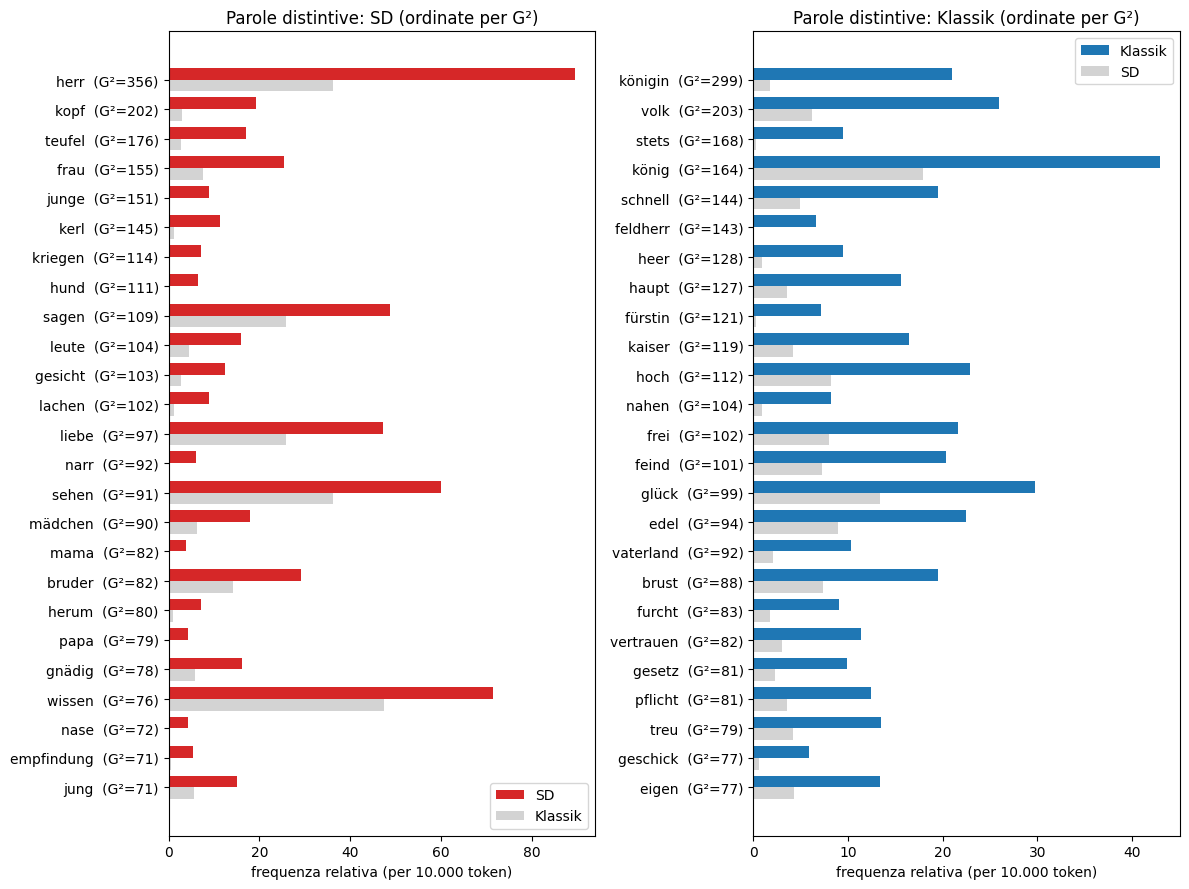

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 9))
for ax, (c, tab, colore) in zip(axes, [("SD", distintive_SD, "tab:red"), ("Klassik", distintive_K, "tab:blue")]):
    altra = [k for k in classi if k != c][0]
    top = tab.head(25)
    y = np.arange(len(top))[::-1]
    ax.barh(y + 0.2, top[f"f_{c} x10k"], height=0.4, color=colore, label=c)
    ax.barh(y - 0.2, top[f"f_{altra} x10k"], height=0.4, color="lightgray", label=altra)
    ax.set_yticks(y); ax.set_yticklabels([f"{w}  (G²={abs(g):.0f})" for w, g in zip(top.index, top["G2"])])
    ax.set_xlabel("frequenza relativa (per 10.000 token)")
    ax.set_title(f"Parole distintive: {c} (ordinate per G²)"); ax.legend()
plt.tight_layout(); plt.show()


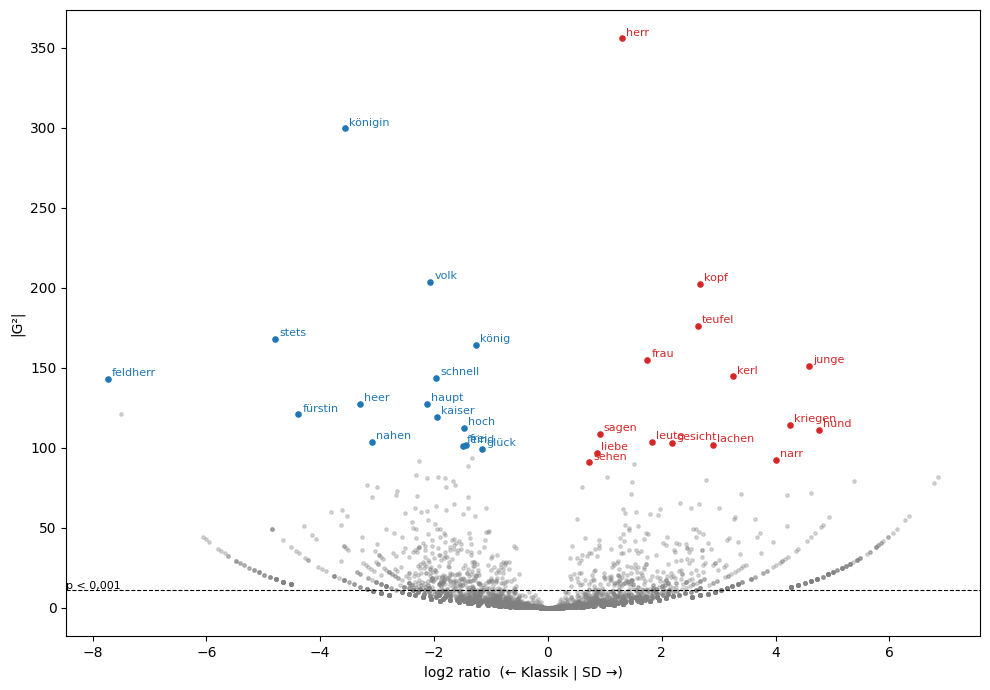

In [ ]:
# Panoramica: effetto (log2 ratio) contro affidabilità (|G2|)
vis = freq[(freq["conteggio_SD"] + freq["conteggio_Klassik"]) >= MIN_COUNT]
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(vis["log2_ratio"], vis["G2"].abs(), s=6, alpha=0.3, color="gray")
for tab, colore in [(distintive_SD.head(15), "tab:red"), (distintive_K.head(15), "tab:blue")]:
    ax.scatter(tab["log2_ratio"], tab["G2"].abs(), s=14, color=colore)
    for w, r in tab.iterrows():
        ax.annotate(w, (r["log2_ratio"], abs(r["G2"])), fontsize=8, color=colore, xytext=(3, 2), textcoords="offset points")
ax.axhline(10.83, ls="--", lw=0.8, color="black"); ax.text(ax.get_xlim()[0], 11.5, "p < 0,001", fontsize=8)
ax.set_xlabel("log2 ratio  (← Klassik | SD >)"); ax.set_ylabel("|G²|")
plt.tight_layout(); plt.show()


## 6. Salvataggio

In [18]:
out = Path(CARTELLA_OUT)
out.mkdir(parents=True, exist_ok=True)
freq.sort_values("G2", ascending=False).to_csv(out / "frequenze_relative.csv")
distintive_SD[colonne].to_csv(out / "distintive_SD.csv")
distintive_K[colonne].to_csv(out / "distintive_Klassik.csv")
elis.to_csv(out / "elisioni_per_opera.csv")
pd.Series(RIPARA, name="forma_piena").to_csv(out / "lemmi_riparati.csv")
print("Salvati in", out)

Salvati in /content/drive/MyDrive/risultati_frequenza
